In [87]:
import os
os.environ["ACCELERATE_SKIP_VERSION_CHECK"] = "1"

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments,
    AutoModel
)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support, roc_auc_score
import random
from collections import Counter
import re
import pandas as pd

In [2]:
dataset = load_dataset("fancyzhx/ag_news")

In [3]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"], 
        padding="max_length", 
        truncation=True, 
        max_length=128
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)

In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"], 
        padding="max_length", 
        truncation=True, 
        max_length=64
    )

tokenized_datasets_2 = dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 7600/7600 [00:00<00:00, 44899.05 examples/s]


In [89]:
df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])

In [94]:
label_mapping = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
df_train["class_name"] = df_train["label"].map(label_mapping)
df_test["class_name"] = df_test["label"].map(label_mapping)

df_train["word_length"] = df_train["text"].apply(lambda x: len(x.split()))
df_test["word_length"] = df_test["text"].apply(lambda x: len(x.split()))

In [95]:
df_train[["label", "text", "class_name"]].head()

,label,text,class_name
0,2,Wall St. Bears Claw Back Into the Black (Reute...,Business
1,2,Carlyle Looks Toward Commercial Aerospace (Reu...,Business
2,2,Oil and Economy Cloud Stocks' Outlook (Reuters...,Business
3,2,Iraq Halts Oil Exports from Main Southern Pipe...,Business
4,2,"Oil prices soar to all-time record, posing new...",Business


/tmp/ipykernel_182889/2815707895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


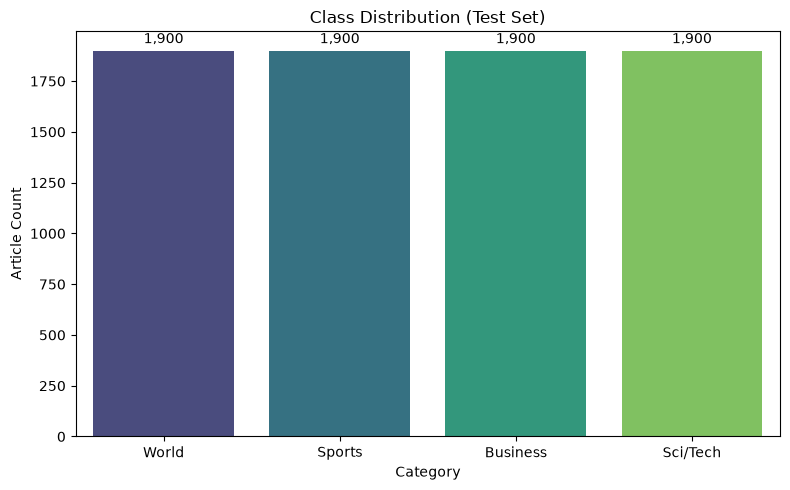

In [111]:
# 3. Create a bar plot of class counts
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df_test,
    x="class_name",
    order=["World", "Sports", "Business", "Sci/Tech"],
    palette="viridis",
)

# Plot formatting
plt.title("Class Distribution (Test Set)")
plt.xlabel("Category")
plt.ylabel("Article Count")

# Add exact frequency labels above each bar
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(
        f"{int(height):,}",
        (patch.get_x() + patch.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

Mean Length: 37.85 words
Standard Deviation: 10.09 words
Minimum Length: 8 words
Maximum Length: 177 words


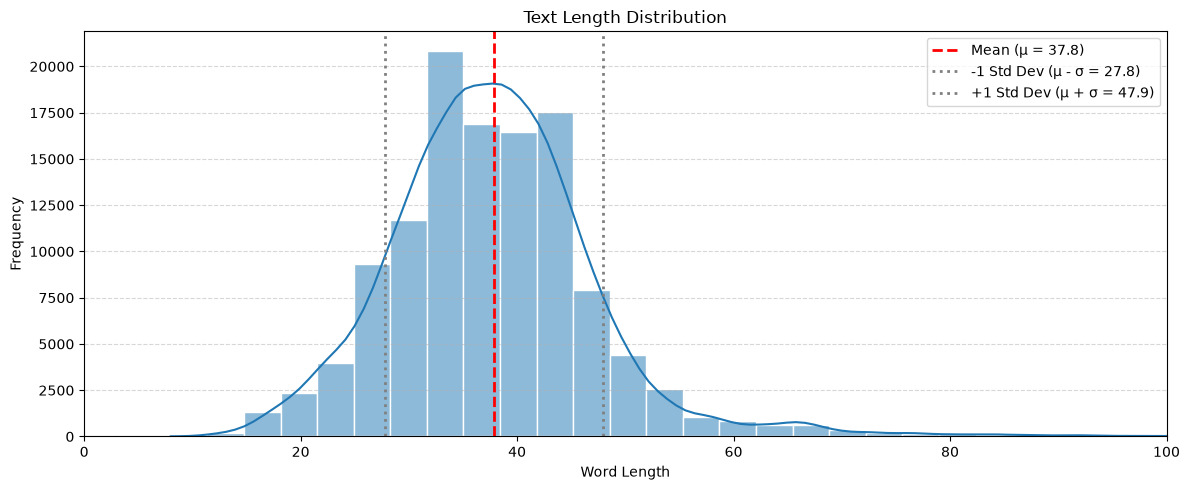

In [119]:
mean_len = df_train["word_length"].mean()
std_len = df_train["word_length"].std()

print(f"Mean Length: {mean_len:.2f} words")
print(f"Standard Deviation: {std_len:.2f} words")
print(f"Minimum Length: {df_train['word_length'].min()} words")
print(f"Maximum Length: {df_train['word_length'].max()} words")

# Create Distribution Plot
plt.figure(figsize=(12, 5))

# Histogram with KDE curve
ax = sns.histplot(
    df_train["word_length"],
    kde=True,
    bins=50,
    edgecolor="white",
)

# Mark Mean
plt.axvline(
    mean_len,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean (μ = {mean_len:.1f})",
)

# Mark Standard Deviations (Mean ± 1 Std Dev)
plt.axvline(
    mean_len - std_len,
    color="grey",
    linestyle=":",
    linewidth=2,
    label=f"-1 Std Dev (μ - σ = {mean_len - std_len:.1f})",
)
plt.axvline(
    mean_len + std_len,
    color="grey",
    linestyle=":",
    linewidth=2,
    label=f"+1 Std Dev (μ + σ = {mean_len + std_len:.1f})",
)

# Formatting
plt.title("Text Length Distribution")
plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xlim(0, 100) 

plt.tight_layout()
plt.show()

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", 
    num_labels=4
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 18682.87it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [121]:
model_small = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", 
    num_labels=4
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 18698.69it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    logging_steps=100,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"], # Sample down if GPU memory/time is limited
    eval_dataset=tokenized_datasets["test"],
)

In [7]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.205905,0.171381
2,0.130060,0.170956
3,0.093248,0.187369


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.62it/s]


TrainOutput(global_step=11250, training_loss=0.15059508171081543, metrics={'train_runtime': 2127.1947, 'train_samples_per_second': 169.237, 'train_steps_per_second': 5.289, 'total_flos': 1.192249110528e+16, 'train_loss': 0.15059508171081543, 'epoch': 3.0})

In [124]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    logging_steps=100,
)

trainer_small = Trainer(
    model=model_small,
    args=training_args,
    train_dataset=tokenized_datasets_2["train"], # Sample down if GPU memory/time is limited
    eval_dataset=tokenized_datasets_2["test"],
)

In [125]:
trainer_small.train()

Epoch,Training Loss,Validation Loss
1,0.204174,0.167926
2,0.112115,0.176376


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.84it/s]


TrainOutput(global_step=7500, training_loss=0.1409571844736735, metrics={'train_runtime': 765.5158, 'train_samples_per_second': 313.514, 'train_steps_per_second': 9.797, 'total_flos': 3974163701760000.0, 'train_loss': 0.1409571844736735, 'epoch': 2.0})

In [8]:
def get_model_predictions(text_list, model, tokenizer):
    inputs = tokenizer(text_list, padding=True, truncation=True, return_tensors="pt").to(model.device)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        # Convert raw logits to probabilities via Softmax
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probs

# Example Inference
sample_text = ["Tech company releases new AI processor today."]
probabilities = get_model_predictions(sample_text, model, tokenizer)

# Output probabilities and chosen prediction
predicted_class = torch.argmax(probabilities, dim=-1).item()
confidence_score = torch.max(probabilities).item()

print(f"Probabilities: {probabilities.cpu().numpy()}")
print(f"Predicted Class ID: {predicted_class}, Confidence: {confidence_score:.4f}")

Probabilities: [[1.9783420e-03 1.3291734e-04 5.8694757e-03 9.9201924e-01]]
Predicted Class ID: 3, Confidence: 0.9920


In [163]:
def predict_sample(sample_id, model, tokenizer, dataset):
    sample = dataset['test'][sample_id]
    text = sample['text']
    label = sample['label']
    
    probabilities = get_model_predictions([text], model, tokenizer)
    predicted_class = torch.argmax(probabilities, dim=-1).item()
    confidence_score = torch.max(probabilities).item()
    probabilities = probabilities.cpu().numpy()
    
    print(f"Sample Text: {text}")
    print(f"probabilities: ({probabilities[0][0]:.4f}, {probabilities[0][1]:.4f}, {probabilities[0][2]:.4f}, {probabilities[0][3]:.4f})")
    print(f"True Label: {label_mapping[label]}")
    print(f"Pred Label: {label_mapping[predicted_class]}, Confidence: {confidence_score:.4f}")

In [168]:
# find wrong prediction
for i in range(24, len(dataset['test'])):
    sample = dataset['test'][i]
    text = sample['text']
    label = sample['label']
    
    probabilities = get_model_predictions([text], model, tokenizer)
    predicted_class = torch.argmax(probabilities, dim=-1).item()
    
    if predicted_class != label:
        print(f"Sample ID: {i}")
        predict_sample(i, model, tokenizer, dataset)
        break

Sample ID: 36
Sample Text: Venezuela Prepares for Chavez Recall Vote Supporters and rivals warn of possible fraud; government says Chavez's defeat could produce turmoil in world oil market.
probabilities: (0.2104, 0.0003, 0.7874, 0.0019)
True Label: World
Pred Label: Business, Confidence: 0.7874


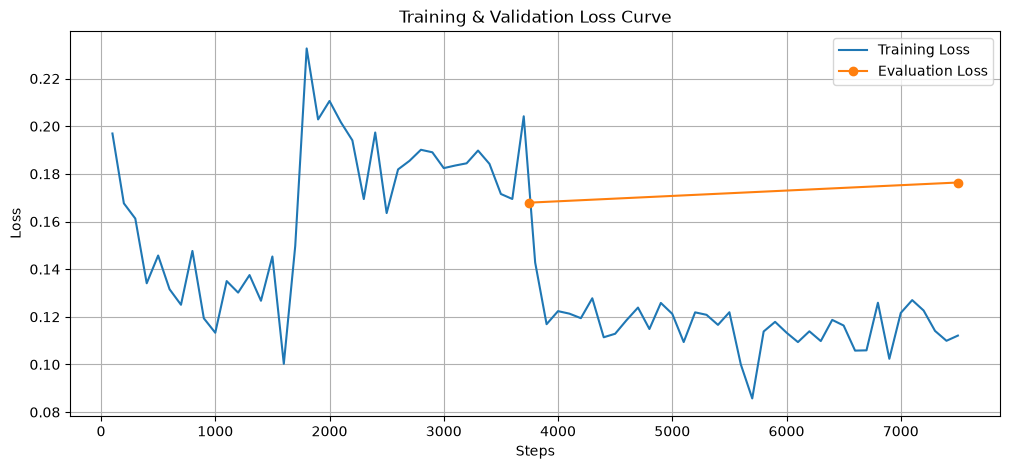

In [127]:
# Extract training and evaluation loss from trainer state
log_history = trainer_small.state.log_history

train_loss = [x["loss"] for x in log_history if "loss" in x]
train_steps = [x["step"] for x in log_history if "loss" in x]

eval_loss = [x["eval_loss"] for x in log_history if "eval_loss" in x]
eval_steps = [x["step"] for x in log_history if "eval_loss" in x]

plt.figure(figsize=(12, 5))
plt.plot(train_steps, train_loss, label="Training Loss")
if eval_loss:
    plt.plot(eval_steps, eval_loss, label="Evaluation Loss", marker="o")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [128]:
# 1. Run predictions on the test dataset
predictions = trainer_small.predict(tokenized_datasets["test"])

# 2. Extract predicted class indices (argmax over logits)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# 3. Print detailed per-class report
target_names = ["World", "Sports", "Business", "Sci/Tech"]
report = classification_report(y_true, y_pred, target_names=target_names, digits=4)

print(report)

              precision    recall  f1-score   support

       World     0.9573    0.9547    0.9560      1900
      Sports     0.9894    0.9842    0.9868      1900
    Business     0.9239    0.9132    0.9185      1900
    Sci/Tech     0.9148    0.9326    0.9236      1900

    accuracy                         0.9462      7600
   macro avg     0.9463    0.9462    0.9462      7600
weighted avg     0.9463    0.9462    0.9462      7600



In [13]:
class SimulatedExpert:
    def __init__(self, target_scores, mode="recall", keyword_rules=None):
        """
        target_scores: dict mapping class_id (0-3) to a float [0.0, 1.0].
                       In 'recall' mode, target_scores[c] = P(predict c | true label is c).
                       In 'precision' mode, target_scores[c] = Precision for class c.
        mode: 'recall' or 'precision'
        keyword_rules: dict mapping keyword string to recall float (e.g., {"ipo": 0.95})
        """
        self.target_scores = target_scores
        self.mode = mode.lower()
        self.keyword_rules = keyword_rules if keyword_rules else {}

    def predict(self, text, true_label):
        text_lower = text.lower()

        # 1. Keyword Recall Overrides (takes precedence if present)
        matching_probs = [
            prob for kw, prob in self.keyword_rules.items() 
            if kw in text_lower
        ]
        if matching_probs and random.random() < max(matching_probs):
            return true_label

        # 2. RECALL Mode Logic
        if self.mode == "recall":
            recall_prob = self.target_scores.get(true_label, 0.5)
            if random.random() < recall_prob:
                return true_label
            else:
                wrong_labels = [c for c in range(4) if c != true_label]
                return random.choice(wrong_labels)

        # 3. PRECISION Mode Logic
        elif self.mode == "precision":
            weights = []
            for candidate_class in range(4):
                precision = self.target_scores.get(candidate_class, 0.5)
                if candidate_class == true_label:
                    weight = precision
                else:
                    weight = 1.0 - precision
                weights.append(weight)

            total_weight = sum(weights)
            if total_weight == 0:
                return random.randint(0, 3)

            probs = [w / total_weight for w in weights]
            return random.choices([0, 1, 2, 3], weights=probs, k=1)[0]

        else:
            raise ValueError(f"Unknown mode '{self.mode}'. Use 'recall' or 'precision'.")

    def evaluate_on_testset(self, test_dataset):
        """Runs the expert across the full test set to compute overall accuracy (Task 2)."""
        correct = sum(
            1 for item in test_dataset 
            if self.predict(item["text"], item["label"]) == item["label"]
        )
        return correct / len(test_dataset)

In [14]:
# Small custom list of common English stop words
STOP_WORDS = {
    'the', 'and', 'for', 'said', 'that', 'with',
    'his', 'was', 'after', 'new', 'its', 'has',
    'will', 'has', 'from', 'are', 'over', 'two',
    'first', 'their', 'have', 'were', 'more',
    'who', 'one', 'but', 'have'
}

def get_top_keywords_per_class(dataset, top_n=20):
    class_names = ["World", "Sports", "Business", "Sci/Tech"]
    class_counters = {0: Counter(), 1: Counter(), 2: Counter(), 3: Counter()}

    # Count word frequencies per class
    for item in dataset["train"]:
        label = item["label"]
        tokens = re.findall(r'\b[a-zA-Z]{3,}\b', item["text"].lower())
        filtered_tokens = [word for word in tokens if word not in STOP_WORDS]
        class_counters[label].update(filtered_tokens)

    # Extract top N keywords per class
    top_words = {}
    for label, counter in class_counters.items():
        top_words[class_names[label]] = [word for word, count in counter.most_common(top_n)]
    
    return top_words

# Usage
top_kw = get_top_keywords_per_class(dataset)
for category, words in top_kw.items():
    print(f"{category}: {words}\n")

World: ['iraq', 'reuters', 'president', 'afp', 'minister', 'killed', 'people', 'government', 'bush', 'quot', 'iraqi', 'prime', 'baghdad', 'monday', 'security', 'wednesday', 'police', 'thursday', 'says', 'nuclear']

Sports: ['game', 'season', 'team', 'win', 'night', 'world', 'out', 'last', 'cup', 'league', 'against', 'year', 'victory', 'this', 'sunday', 'three', 'quot', 'coach', 'when', 'not']

Business: ['reuters', 'oil', 'stocks', 'inc', 'company', 'prices', 'fullquote', 'percent', 'york', 'year', 'corp', 'profit', 'million', 'quarter', 'sales', 'monday', 'billion', 'wednesday', 'tuesday', 'thursday']

Sci/Tech: ['microsoft', 'software', 'reuters', 'internet', 'company', 'space', 'quot', 'this', 'inc', 'search', 'com', 'computer', 'service', 'security', 'music', 'world', 'web', 'year', 'technology', 'online']



In [185]:
# topic accuracy mapping: {0: World, 1: Sports, 2: Business, 3: Sci/Tech}
base_accs = {0: 0.9, 1: 0.3, 2: 0.95, 3: 0.6} 

# Custom keyword overrides
keyword_overrides = {
    "company": 1.0,
    "inc": 1.0,
    "world": 1.0,
    "president": 1.0,
    "government": 1.0,
    "iraq": 1.0,
    "iraqi": 1.0,
}

# expert_test = SimulatedExpert(
#     target_scores={0: 0.70, 1: 0.99, 2: 0.40, 3: 0.90},
#     mode="precision"
# )

expert = SimulatedExpert(target_scores=base_accs, keyword_rules=keyword_overrides, mode="recall")

# Evaluate stand-alone performance on test set
test_accuracy = expert.evaluate_on_testset(dataset["test"])
print(f"Simulated Expert Test Accuracy: {test_accuracy * 100:.2f}%")

Simulated Expert Test Accuracy: 75.99%


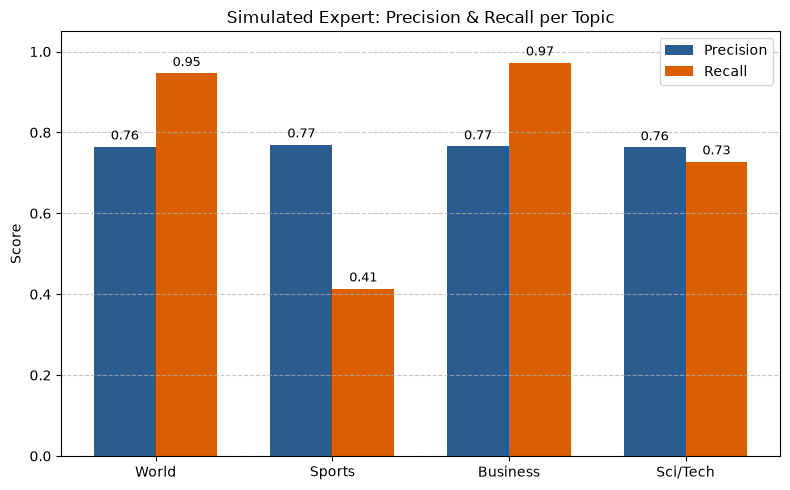

In [186]:
# 1. Collect predictions from expert on the test dataset
y_true = [item["label"] for item in dataset["test"]]
y_pred = [expert.predict(item["text"], item["label"]) for item in dataset["test"]]

# 2. Compute classification metrics as a dictionary
target_names = ["World", "Sports", "Business", "Sci/Tech"]
report_dict = classification_report(
    y_true, y_pred, target_names=target_names, output_dict=True
)

# 3. Extract precision and recall values for each category
precision_vals = [report_dict[category]["precision"] for category in target_names]
recall_vals = [report_dict[category]["recall"] for category in target_names]

# 4. Plot side-by-side bar chart
x = np.arange(len(target_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, precision_vals, width, label='Precision', color='#2b5c8f')
rects2 = ax.bar(x + width/2, recall_vals, width, label='Recall', color='#d95f02')

ax.set_ylabel('Score')
ax.set_title('Simulated Expert: Precision & Recall per Topic')
ax.set_xticks(x)
ax.set_xticklabels(target_names)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact numeric values above bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [17]:
def extract_probs_and_preds(predictions):
    logits = predictions.predictions
    # Compute Softmax probabilities
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    confidences = np.max(probs, axis=1, keepdims=True)
    model_preds = np.argmax(probs, axis=1)
    return probs, confidences, model_preds

train_preds = trainer.predict(tokenized_datasets["train"])
test_preds = trainer.predict(tokenized_datasets["test"])

train_probs, train_conf, train_model_preds = extract_probs_and_preds(train_preds)
test_probs, test_conf, test_model_preds = extract_probs_and_preds(test_preds)

y_train = np.array(dataset["train"]["label"])
y_test = np.array(dataset["test"]["label"])

In [229]:
# 2. Instantiate Expert & Generate Predictions
expert = SimulatedExpert(
    target_scores={0: 0.95, 1: 0.3, 2: 0.98, 3: 0.8} ,
    mode="recall",
    keyword_rules={
        "company": 1.0,
        "inc": 1.0,
        "world": 1.0,
        "president": 1.0,
        "government": 1.0,
        "iraq": 1.0,
        "iraqi": 1.0,
    }
)

m_train = np.array([expert.predict(item["text"], item["label"]) for item in dataset["train"]])
m_test = np.array([expert.predict(item["text"], item["label"]) for item in dataset["test"]])

# 3. Create Training Target for the Deferral Classifier
# Defer (1) if the Expert is CORRECT and the Primary Model is WRONG; else keep model (0)
expert_correct_train = (m_train == y_train)
model_correct_train = (train_model_preds == y_train)

y_defer_train = (expert_correct_train & (~model_correct_train)).astype(int)

# 4. Build Deferral Features (Model Class Probabilities + Max Confidence)
X_defer_train = np.hstack([train_probs, train_conf])
X_defer_test = np.hstack([test_probs, test_conf])

# 5. Train External Deferral Classifier
defer_classifier = LogisticRegression(class_weight="balanced")
defer_classifier.fit(X_defer_train, y_defer_train)

# 6. Inference and Evaluation on Test Set
# Extract probability that deferring is beneficial
defer_probs = defer_classifier.predict_proba(X_defer_test)[:, 1]

# Defer cost (penalty for asking the human)
accuracies = []
coverages = []
costs = []
res = 50
for i in range(res):
    query_cost = 0.0 + 0.55 * i / res
    costs.append(query_cost)
    defer_decisions = (defer_probs > (0.5 + query_cost)).astype(int)
    final_predictions = np.where(defer_decisions == 1, m_test, test_model_preds)
    coverage = np.mean(defer_decisions == 0)
    system_acc = accuracy_score(y_test, final_predictions)
    
    accuracies.append(system_acc)
    coverages.append(coverage)

query_cost = 0.45

# Only defer if confidence in expert superiority outweighs query cost
defer_decisions = (defer_probs > (0.5 + query_cost)).astype(int)

# Combine outputs based on deferral decisions
final_predictions = np.where(defer_decisions == 1, m_test, test_model_preds)

# Calculate System Performance Metrics
coverage = np.mean(defer_decisions == 0)  # Fraction of predictions made by AI model
system_acc = accuracy_score(y_test, final_predictions)
model_acc = accuracy_score(y_test, test_model_preds)
expert_acc = accuracy_score(y_test, m_test)

print(f"Model Standalone Accuracy:      {model_acc * 100:.2f}%")
print(f"Expert Standalone Accuracy:     {expert_acc * 100:.2f}%")
print(f"Phase 1 Combined System Acc:    {system_acc * 100:.2f}%")
print(f"Model Coverage (Not Deferred): {coverage * 100:.2f}%")

Model Standalone Accuracy:      94.53%
Expert Standalone Accuracy:     80.67%
Phase 1 Combined System Acc:    96.12%
Model Coverage (Not Deferred): 95.62%


In [225]:
# 2. Instantiate Expert & Generate Predictions
expert_1 = SimulatedExpert(
    target_scores={0: 0.95, 1: 0.99, 2: 0.9, 3: 0.98} ,
    mode="recall",
    keyword_rules={
        "company": 1.0,
        "inc": 1.0,
        "world": 1.0,
        "president": 1.0,
        "government": 1.0,
        "iraq": 1.0,
        "iraqi": 1.0,
    }
)

expert_2 = SimulatedExpert(
    target_scores={0: 0.95, 1: 0.3, 2: 0.98, 3: 0.8} ,
    mode="recall",
    keyword_rules={
        "company": 1.0,
        "inc": 1.0,
        "world": 1.0,
        "president": 1.0,
        "government": 1.0,
        "iraq": 1.0,
        "iraqi": 1.0,
    }
)

m_train_1 = np.array([expert_1.predict(item["text"], item["label"]) for item in dataset["train"]])
m_train_2 = np.array([expert_2.predict(item["text"], item["label"]) for item in dataset["train"]])
m_test_1 = np.array([expert_1.predict(item["text"], item["label"]) for item in dataset["test"]])
m_test_2 = np.array([expert_2.predict(item["text"], item["label"]) for item in dataset["test"]])

# 3. Create Training Target for the Deferral Classifier
# Defer (1) if the Expert is CORRECT and the Primary Model is WRONG; else keep model (0)
expert_1_correct_train = (m_train_1 == y_train)
expert_2_correct_train = (m_train_2 == y_train)
model_correct_train = (train_model_preds == y_train)

# Defer to Expert 1 (1) if Expert 1 is CORRECT and Primary Model is WRONG
y_defer_train_1 = ((m_train_1 == y_train) & (train_model_preds != y_train)).astype(int)

# Defer to Expert 2 (1) if Expert 2 is CORRECT and Primary Model is WRONG
y_defer_train_2 = ((m_train_2 == y_train) & (train_model_preds != y_train)).astype(int)

# 4. Build Deferral Features (Model Class Probabilities + Max Confidence)
X_defer_train = np.hstack([train_probs, train_conf])
X_defer_test = np.hstack([test_probs, test_conf])

# 5. Train Two Independent External Deferral Classifiers
defer_clf_1 = LogisticRegression(class_weight="balanced")
defer_clf_1.fit(X_defer_train, y_defer_train_1)

defer_clf_2 = LogisticRegression(class_weight="balanced")
defer_clf_2.fit(X_defer_train, y_defer_train_2)

# 6. Inference and Evaluation on Test Set
# Extract independent probabilities that deferring to each expert is beneficial
defer_probs_1 = defer_clf_1.predict_proba(X_defer_test)[:, 1]
defer_probs_2 = defer_clf_2.predict_proba(X_defer_test)[:, 1]

query_cost = 0.0
threshold = 0.5 + query_cost

# Mask indicating which experts cross the deferral threshold
defer_mask_1 = defer_probs_1 > threshold
defer_mask_2 = defer_probs_2 > threshold

# Determine final predictions per sample:
# Default: Keep Primary Model predictions
final_predictions = test_model_preds.copy()
defer_decisions = np.zeros(len(y_test), dtype=int)  # 0: Model, 1: Expert 1, 2: Expert 2

accuracies = []
coverages = []
costs = []
res = 20

for i in range(res):
    query_cost = 0.0 + 0.5 * i / res
    costs.append(query_cost)
    threshold = 0.5 + query_cost
    
    defer_mask_1 = defer_probs_1 > threshold
    defer_mask_2 = defer_probs_2 > threshold
    
    # Selection logic:
    # 1. Both active -> pick expert with higher confidence
    # 2. Only E1 active -> pick E1
    # 3. Only E2 active -> pick E2
    # 4. Neither active -> pick Primary Model
    cond_e1 = (defer_mask_1 & ~defer_mask_2) | (defer_mask_1 & defer_mask_2 & (defer_probs_1 >= defer_probs_2))
    cond_e2 = (~defer_mask_1 & defer_mask_2) | (defer_mask_1 & defer_mask_2 & (defer_probs_2 > defer_probs_1))
    
    final_predictions = np.select(
        [cond_e1, cond_e2],
        [m_test_1, m_test_2],
        default=test_model_preds
    )
    
    defer_decisions = np.select([cond_e1, cond_e2], [1, 2], default=0)
    
    coverage = np.mean(defer_decisions == 0)
    system_acc = accuracy_score(y_test, final_predictions)
    
    accuracies.append(system_acc)
    coverages.append(coverage)

# Single evaluation baseline at zero query cost
query_cost = 0.0
threshold = 0.5 + query_cost

defer_mask_1 = defer_probs_1 > threshold
defer_mask_2 = defer_probs_2 > threshold

cond_e1 = (defer_mask_1 & ~defer_mask_2) | (defer_mask_1 & defer_mask_2 & (defer_probs_1 >= defer_probs_2))
cond_e2 = (~defer_mask_1 & defer_mask_2) | (defer_mask_1 & defer_mask_2 & (defer_probs_2 > defer_probs_1))

final_predictions = np.select([cond_e1, cond_e2], [m_test_1, m_test_2], default=test_model_preds)
defer_decisions = np.select([cond_e1, cond_e2], [1, 2], default=0)

# Calculate System Performance Metrics
coverage = np.mean(defer_decisions == 0)
pct_expert_1 = np.mean(defer_decisions == 1)
pct_expert_2 = np.mean(defer_decisions == 2)

system_acc = accuracy_score(y_test, final_predictions)
model_acc = accuracy_score(y_test, test_model_preds)
expert_1_acc = accuracy_score(y_test, m_test_1)
expert_2_acc = accuracy_score(y_test, m_test_2)

print(f"Model Standalone Accuracy:      {model_acc * 100:.2f}%")
print(f"Expert 1 Standalone Accuracy:   {expert_1_acc * 100:.2f}%")
print(f"Expert 2 Standalone Accuracy:   {expert_2_acc * 100:.2f}%")
print(f"Phase 1 Combined System Acc:    {system_acc * 100:.2f}%")
print(f"Model Coverage (Not Deferred): {coverage * 100:.2f}%")
print(f"Deferred to Expert 1:           {pct_expert_1 * 100:.2f}%")
print(f"Deferred to Expert 2:           {pct_expert_2 * 100:.2f}%")

Model Standalone Accuracy:      94.53%
Expert 1 Standalone Accuracy:   97.09%
Expert 2 Standalone Accuracy:   81.14%
Phase 1 Combined System Acc:    97.30%
Model Coverage (Not Deferred): 88.64%
Deferred to Expert 1:           4.07%
Deferred to Expert 2:           7.29%


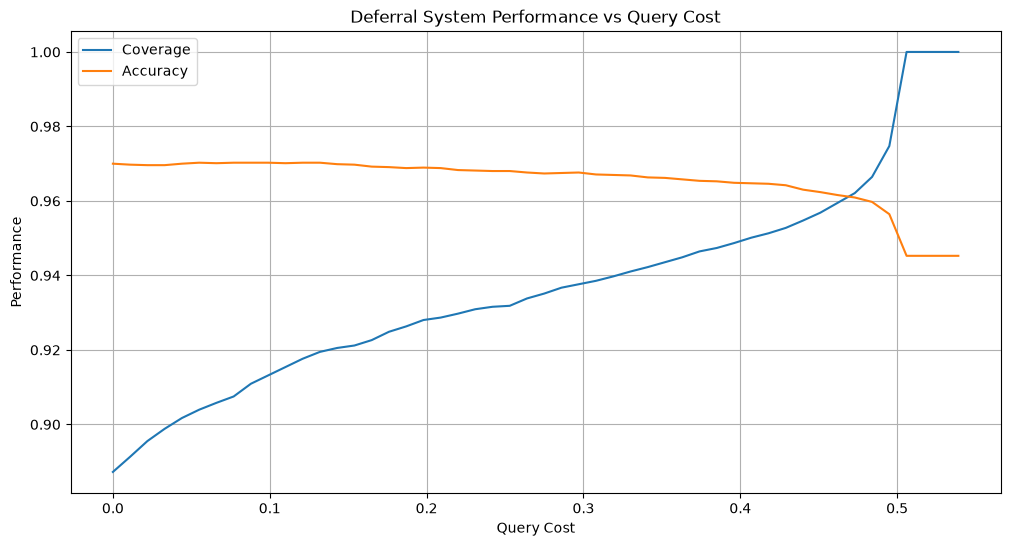

In [227]:
plt.figure(figsize=(12, 6))
plt.plot(costs, coverages)
plt.plot(costs, accuracies)
plt.legend(["Coverage", "Accuracy"])
plt.grid()
plt.xlabel("Query Cost")
plt.ylabel("Performance")
plt.title("Deferral System Performance vs Query Cost")
plt.show()

In [231]:
# Define Expert 1 (Sports & Tech focus)
expert_1 = SimulatedExpert(
    target_scores={0: 0.70, 1: 0.99, 2: 0.40, 3: 0.99},
    mode="precision"
)

# Define Expert 2 (World & Business focus)
expert_2 = SimulatedExpert(
    target_scores={0: 0.99, 1: 0.45, 2: 0.99, 3: 0.60},
    mode="precision"
)

experts = [expert_1, expert_2]
M = len(experts)  # Number of experts = 2
K = 4             # Number of AG News categories
num_labels = K + M # Total logits = 6

# Pre-generate expert predictions for train and test sets
train_expert_preds = np.column_stack([
    [exp.predict(item["text"], item["label"]) for item in dataset["train"]]
    for exp in experts
]) # Shape: (N_train, M)

test_expert_preds = np.column_stack([
    [exp.predict(item["text"], item["label"]) for item in dataset["test"]]
    for exp in experts
])  # Shape: (N_test, M)

In [232]:
# 2. Robust CSSLossTrainer method using safe key extractions
class CostSensitiveL2DTrainer(Trainer):
    def __init__(self, *args, expert_preds_train=None, query_cost=0.005, K=4, **kwargs):
        super().__init__(*args, **kwargs)
        # Convert expert predictions matrix (Shape: N x M) to tensor
        self.expert_preds_train = torch.tensor(expert_preds_train, dtype=torch.long)
        self.query_cost = query_cost
        self.K = K
        self.M = self.expert_preds_train.shape[1]

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels", inputs.get("label"))
        idx = inputs.get("idx")

        model_inputs = {}
        if "input_ids" in inputs:
            model_inputs["input_ids"] = inputs["input_ids"]
        if "attention_mask" in inputs:
            model_inputs["attention_mask"] = inputs["attention_mask"]

        outputs = model(**model_inputs)
        logits = outputs.get("logits")  # Shape: (Batch_Size, K + M)
        batch_size = logits.size(0)

        # 1. Fetch expert predictions for the batch
        if idx is not None:
            m_batch = self.expert_preds_train[idx.cpu()].to(logits.device)
        else:
            m_batch = torch.zeros((batch_size, self.M), dtype=torch.long, device=logits.device)

        # 2. Build Cost Matrix c(k, x, y) of shape (Batch_Size, K + M)
        costs = torch.zeros((batch_size, self.K + self.M), device=logits.device)

        # Base classifier options (1..K)
        for k in range(self.K):
            costs[:, k] = (labels != k).float()

        # Expert deferral options (K+1..K+M)
        for m_idx in range(self.M):
            expert_m_preds = m_batch[:, m_idx]
            costs[:, self.K + m_idx] = (labels != expert_m_preds).float() + self.query_cost

        # 3. Compute CSS Weight: max_{k'} c(k', x, y) - c(k, x, y)
        max_costs, _ = torch.max(costs, dim=1, keepdim=True)
        weights = max_costs - costs  # Lower cost options get higher weight

        # 4. Compute Log Softmax over all K + M actions
        log_probs = F.log_softmax(logits, dim=1)  # Shape: (Batch_Size, K + M)

        # 5. Weighted Cross-Entropy Loss (CSS Loss)
        # Multiply weights by log probabilities and average over batch
        loss = -torch.sum(weights * log_probs, dim=1).mean()

        return (loss, outputs) if return_outputs else loss

In [245]:
# Add sample indices to datasets to track expert predictions in batches
# 1. Add the idx column to your ALREADY TOKENIZED dataset
tokenized_with_idx = tokenized_datasets.map(
    lambda item, idx: {"idx": idx}, 
    with_indices=True
)

# 2. Set format on the tokenized dataset
tokenized_with_idx.set_format(
    type="torch", 
    columns=["input_ids", "attention_mask", "label", "idx"]
)

# Load pretrained model with expanded classification head
model2 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)

training_args = TrainingArguments(
    output_dir="./phase2_l2d_model",
    learning_rate=2e-5,
    per_device_train_batch_size=32,  # Increased batch size to speed up further
    per_device_eval_batch_size=64,
    num_train_epochs=1,
    weight_decay=0.01,
    eval_strategy="no",
    save_strategy="no",              # Prevents slow disk saving steps
    logging_steps=100
)

trainer_phase2 = CostSensitiveL2DTrainer(
    model=model2,
    args=training_args,
    # Use .select() for the HuggingFace Dataset
    train_dataset=tokenized_with_idx["train"].select(range(10000)),
    # Use standard array/tensor slicing for NumPy/PyTorch expert predictions
    expert_preds_train=train_expert_preds[:10000],
    query_cost=0.1
)

# Train Phase 2 Model
trainer_phase2.train()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 18779.91it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,2.445359
200,1.976663
300,2.004282


TrainOutput(global_step=313, training_loss=2.139069864925104, metrics={'train_runtime': 58.5481, 'train_samples_per_second': 170.8, 'train_steps_per_second': 5.346, 'total_flos': 331192120320000.0, 'train_loss': 2.139069864925104, 'epoch': 1.0})

In [246]:
# 1. Run model inference on test set
raw_test_preds = trainer_phase2.predict(tokenized_with_idx["test"])


In [247]:

logits = raw_test_preds.predictions.copy()  # Shape: (N_test, 6)

# Boost the expert logits slightly at test time
deferral_bias = 0.0  # Adjust between 0.5 and 3.0 to control coverage
logits[:, 4:] += deferral_bias

# Re-run decision rule
decisions = np.argmax(logits, axis=1)

y_test = np.array(dataset["test"]["label"])
final_preds = np.zeros_like(y_test)

ai_predicted = (decisions < 4)
deferred_to_e1 = (decisions == 4)
deferred_to_e2 = (decisions == 5)

final_preds[ai_predicted] = decisions[ai_predicted]
final_preds[deferred_to_e1] = test_expert_preds[deferred_to_e1, 0]
final_preds[deferred_to_e2] = test_expert_preds[deferred_to_e2, 1]

print(f"Overall System Accuracy: {np.mean(final_preds == y_test) * 100:.2f}%")
print(f"AI Coverage (Self-predicted): {np.mean(ai_predicted) * 100:.2f}%")
print(f"Deferred to Expert 1 (Sports/Tech): {np.mean(deferred_to_e1) * 100:.2f}%")
print(f"Deferred to Expert 2 (World/Biz):   {np.mean(deferred_to_e2) * 100:.2f}%")

Overall System Accuracy: 89.64%
AI Coverage (Self-predicted): 99.24%
Deferred to Expert 1 (Sports/Tech): 0.47%
Deferred to Expert 2 (World/Biz):   0.29%


In [32]:
class L2DTransformer(nn.Module):
    def __init__(self, model_name, num_classes=4, num_experts=2):
        super().__init__()
        # Load backbone (e.g. distilbert-base-uncased)
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        
        # Head 1: Main Classifier (Standard 4-class Softmax)
        self.classifier = nn.Linear(hidden_size, num_classes)
        
        # Head 2: Expert Deferral Gates (M binary Sigmoids)
        self.expert_gates = nn.Linear(hidden_size, num_experts)

    def forward(self, input_ids=None, attention_mask=None, **kwargs):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # Use [CLS] token / pooled embedding
        cls_rep = outputs.last_hidden_state[:, 0, :]
        
        class_logits = self.classifier(cls_rep)    # Shape: (Batch, K)
        gate_logits = self.expert_gates(cls_rep)    # Shape: (Batch, M)
        
        return class_logits, gate_logits

In [ ]:
class MultiTaskL2DTrainer(Trainer):
    def __init__(self, *args, expert_preds_train=None, query_cost=0.05, **kwargs):
        super().__init__(*args, **kwargs)
        self.expert_preds_train = torch.tensor(expert_preds_train, dtype=torch.long)
        self.query_cost = query_cost
        self.ce_loss = nn.CrossEntropyLoss()
        pos_weight = torch.tensor([25.0, 25.0], device=logits.device)
        self.bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        #self.bce_loss = nn.BCEWithLogitsLoss()

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels", inputs.get("label"))
        idx = inputs.get("idx")
        
        class_logits, gate_logits = model(
            input_ids=inputs["input_ids"], 
            attention_mask=inputs["attention_mask"]
        )
        
        # 1. Main Classification Loss
        loss_cls = self.ce_loss(class_logits, labels)
        
        # 2. Derive Deferral Targets based on Model Accuracy vs Expert Accuracy + Cost
        with torch.no_grad():
            ai_preds = torch.argmax(class_logits, dim=-1)
            ai_errors = (ai_preds != labels).float() # 1 if AI wrong, 0 if correct
            
            m_batch = self.expert_preds_train[idx.cpu()].to(class_logits.device)
            
            # Construct binary target for each expert
            gate_targets = torch.zeros_like(gate_logits)
            for m in range(gate_logits.size(1)):
                expert_m_errors = (m_batch[:, m] != labels).float()
                
                # Expert is beneficial if: AI is Wrong (Cost 1) AND Expert is Right (Cost 0 + query_cost)
                # i.e., Cost(AI) - Cost(Expert) > 0 => 1 - (0 + query_cost) = 1 - query_cost > 0
                beneficial = (ai_errors == 1) & (expert_m_errors == 0)
                gate_targets[:, m] = beneficial.float()

        # 3. Expert Gate Loss
        loss_gate = self.bce_loss(gate_logits, gate_targets)
        
        # Total loss: Primary task classification + Expert gating
        total_loss = loss_cls + loss_gate
        
        return (total_loss, (class_logits, gate_logits)) if return_outputs else total_loss

In [48]:
class ExpertAccuracyL2DTrainer(Trainer):
    def __init__(self, *args, expert_preds_train=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.expert_preds_train = torch.tensor(expert_preds_train, dtype=torch.long)
        self.ce_loss = nn.CrossEntropyLoss()
        self.bce_loss = nn.BCEWithLogitsLoss()

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels", inputs.get("label"))
        idx = inputs.get("idx")
        
        class_logits, gate_logits = model(
            input_ids=inputs["input_ids"], 
            attention_mask=inputs["attention_mask"]
        )
        
        # 1. Main Classification Loss
        loss_cls = self.ce_loss(class_logits, labels)
        
        # 2. Gate targets: Is Expert m CORRECT on this sample?
        m_batch = self.expert_preds_train[idx.cpu()].to(class_logits.device)
        gate_targets = torch.zeros_like(gate_logits)
        
        for m in range(gate_logits.size(1)):
            # Target = 1.0 if expert was right, 0.0 if wrong
            gate_targets[:, m] = (m_batch[:, m] == labels).float()

        # 3. Expert correctness loss
        loss_gate = self.bce_loss(gate_logits, gate_targets)
        
        total_loss = loss_cls + loss_gate
        return (total_loss, (class_logits, gate_logits)) if return_outputs else total_loss

In [49]:
def predict_l2d(model, eval_dataloader, expert_preds_test, threshold=0.5):
    model.eval()
    all_final_preds = []
    decisions = [] # 0: AI, 1: Expert 1, 2: Expert 2 ...
    
    with torch.no_grad():
        for batch in eval_dataloader:
            class_logits, gate_logits = model(
                input_ids=batch["input_ids"].cuda(), 
                attention_mask=batch["attention_mask"].cuda()
            )
            
            ai_probs = torch.softmax(class_logits, dim=-1)
            ai_preds = torch.argmax(ai_probs, dim=-1)
            
            gate_probs = torch.sigmoid(gate_logits) # Shape: (Batch, M)
            
            for i in range(len(ai_preds)):
                # Check if any expert gate exceeds deferral threshold
                max_gate_val, best_expert = torch.max(gate_probs[i], dim=-1)
                
                if max_gate_val > threshold:
                    # Defer to best expert
                    expert_choice = best_expert.item()
                    expert_pred = expert_preds_test[batch["idx"][i]][expert_choice]
                    all_final_preds.append(expert_pred)
                    decisions.append(1 + expert_choice)
                else:
                    # Keep AI prediction
                    all_final_preds.append(ai_preds[i].item())
                    decisions.append(0)
                    
    return np.array(all_final_preds), np.array(decisions)

In [57]:
# Create 10k subset for fast iteration
subset_train = tokenized_with_idx["train"].select(range(10000))
subset_expert_preds = train_expert_preds[:10000]

model3 = L2DTransformer(
    model_name="distilbert-base-uncased", 
    num_classes=4, 
    num_experts=2
)

training_args = TrainingArguments(
    output_dir="./phase2_multihead_10k",
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy="no",
    eval_strategy="no",
    remove_unused_columns=False
)

trainer = ExpertAccuracyL2DTrainer(
    model=model3,
    args=training_args,
    train_dataset=subset_train,
    expert_preds_train=subset_expert_preds,
)

trainer.train()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 15377.83it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Step,Training Loss
50,1.340820
100,1.073462
150,1.020699
200,0.995744
250,0.981958
300,0.945642
350,0.895807
400,0.882544
450,0.861945
500,0.838729


TrainOutput(global_step=939, training_loss=0.8984465350231297, metrics={'train_runtime': 176.244, 'train_samples_per_second': 170.219, 'train_steps_per_second': 5.328, 'total_flos': 0.0, 'train_loss': 0.8984465350231297, 'epoch': 3.0})

In [58]:
# 1. Run trainer.predict ONCE
raw_test_preds = trainer.predict(tokenized_with_idx["test"])
class_logits, gate_logits = raw_test_preds.predictions

# 2. Extract AI predictions and confidence scores (Softmax max probability)
ai_probs = torch.softmax(torch.tensor(class_logits), dim=-1).numpy()
ai_preds = np.argmax(ai_probs, axis=-1)
ai_confidence = np.max(ai_probs, axis=-1)

# 3. Extract Expert correctness probabilities (Sigmoids)
expert_corr_probs = 1 / (1 + np.exp(-gate_logits))

# 4. Extract ground truth labels and expert predictions
y_test = np.array(tokenized_with_idx["test"]["label"])

In [59]:
def evaluate_threshold(threshold=0.0):
    N = len(y_test)
    final_preds = np.zeros(N, dtype=int)
    decisions = np.zeros(N, dtype=int)  # 0: AI, 1: Expert 1, 2: Expert 2
    
    for i in range(N):
        # Pick the expert with the highest predicted probability of being correct
        best_expert = np.argmax(expert_corr_probs[i])
        best_expert_prob = expert_corr_probs[i][best_expert]
        
        # Defer condition: Defer if (1 - AI_Confidence) > (1 - Expert_Prob) + threshold
        # Or equivalently: Expert_Prob - AI_Confidence > threshold
        if (best_expert_prob - ai_confidence[i]) > threshold:
            final_preds[i] = test_expert_preds[i, best_expert]
            decisions[i] = 1 + best_expert
        else:
            final_preds[i] = ai_preds[i]
            decisions[i] = 0

    acc = np.mean(final_preds == y_test) * 100
    ai_cov = np.mean(decisions == 0) * 100
    e1_cov = np.mean(decisions == 1) * 100
    e2_cov = np.mean(decisions == 2) * 100

    print(f"--- Threshold: {threshold:+.2f} ---")
    print(f"Overall System Accuracy: {acc:.2f}%")
    print(f"AI Coverage (Self-predicted): {ai_cov:.2f}%")
    print(f"Deferred to Expert 1 (Sports/Tech): {e1_cov:.2f}%")
    print(f"Deferred to Expert 2 (World/Biz):   {e2_cov:.2f}%\n")

# Sweep thresholds instantly
for t in [-0.2, -0.1, 0.0, 0.05, 0.1, 0.2]:
    evaluate_threshold(threshold=t)

--- Threshold: -0.20 ---
Overall System Accuracy: 91.41%
AI Coverage (Self-predicted): 94.26%
Deferred to Expert 1 (Sports/Tech): 4.12%
Deferred to Expert 2 (World/Biz):   1.62%

--- Threshold: -0.10 ---
Overall System Accuracy: 91.74%
AI Coverage (Self-predicted): 96.47%
Deferred to Expert 1 (Sports/Tech): 2.59%
Deferred to Expert 2 (World/Biz):   0.93%

--- Threshold: +0.00 ---
Overall System Accuracy: 91.80%
AI Coverage (Self-predicted): 98.32%
Deferred to Expert 1 (Sports/Tech): 1.21%
Deferred to Expert 2 (World/Biz):   0.47%

--- Threshold: +0.05 ---
Overall System Accuracy: 91.76%
AI Coverage (Self-predicted): 99.03%
Deferred to Expert 1 (Sports/Tech): 0.74%
Deferred to Expert 2 (World/Biz):   0.24%

--- Threshold: +0.10 ---
Overall System Accuracy: 91.71%
AI Coverage (Self-predicted): 99.61%
Deferred to Expert 1 (Sports/Tech): 0.29%
Deferred to Expert 2 (World/Biz):   0.11%

--- Threshold: +0.20 ---
Overall System Accuracy: 91.67%
AI Coverage (Self-predicted): 99.95%
Deferred to

In [62]:
# 1. Ground truth correctness of experts on test set
# (1.0 if expert got the sample right, 0.0 if wrong)
y_test_arr = np.array(tokenized_with_idx["test"]["label"])
e1_actual_correct = (test_expert_preds[:, 0] == y_test_arr).astype(int)
e2_actual_correct = (test_expert_preds[:, 1] == y_test_arr).astype(int)

# 2. Predicted correctness from gating head (thresholded at 0.5 probability)
e1_pred_correct = (expert_corr_probs[:, 0] >= 0.5).astype(int)
e2_pred_correct = (expert_corr_probs[:, 1] >= 0.5).astype(int)

print("=== Expert 1 (Sports/Tech) Gate Performance ===")
p1, r1, f1, _ = precision_recall_fscore_support(e1_actual_correct, e1_pred_correct, average='binary')
print(f"Precision: {p1*100:.2f}% | Recall: {r1*100:.2f}% | F1: {f1*100:.2f}%")
print(f"Actual Accuracy of Expert 1: {np.mean(e1_actual_correct)*100:.2f}%")
print(f"Predicted Avg Prob Expert 1: {np.mean(expert_corr_probs[:, 0])*100:.2f}%\n")

print("=== Expert 2 (World/Biz) Gate Performance ===")
p2, r2, f2, _ = precision_recall_fscore_support(e2_actual_correct, e2_pred_correct, average='binary')
print(f"Precision: {p2*100:.2f}% | Recall: {r2*100:.2f}% | F1: {f1*100:.2f}%")
print(f"Actual Accuracy of Expert 2: {np.mean(e2_actual_correct)*100:.2f}%")
print(f"Predicted Avg Prob Expert 2: {np.mean(expert_corr_probs[:, 2] if expert_corr_probs.shape[1]>2 else expert_corr_probs[:, 1])*100:.2f}%\n")

=== Expert 1 (Sports/Tech) Gate Performance ===
Precision: 52.30% | Recall: 74.48% | F1: 61.45%
Actual Accuracy of Expert 1: 52.79%
Predicted Avg Prob Expert 1: 53.44%

=== Expert 2 (World/Biz) Gate Performance ===
Precision: 51.42% | Recall: 62.35% | F1: 61.45%
Actual Accuracy of Expert 2: 50.71%
Predicted Avg Prob Expert 2: 50.94%



In [65]:
# Ground truth correctness arrays (1.0 = Expert correct, 0.0 = Expert wrong)
y_train_arr = np.array(tokenized_with_idx["train"]["label"])
y_test_arr  = np.array(tokenized_with_idx["test"]["label"])

# Target shapes: (N, 2)
gate_targets_train = (train_expert_preds == y_train_arr[:, None]).astype(np.float32)
gate_targets_test  = (test_expert_preds == y_test_arr[:, None]).astype(np.float32)

# Select the 10k subset
gate_dataset_train = tokenized_with_idx["train"].select(range(10000))
gate_dataset_test  = tokenized_with_idx["test"]

# Add target column 'labels' expected by HuggingFace BCEWithLogitsLoss
def add_labels(example, idx):
    return {"labels": gate_targets_train[idx]}

def add_labels_test(example, idx):
    return {"labels": gate_targets_test[idx]}

gate_dataset_train = gate_dataset_train.map(add_labels, with_indices=True)
gate_dataset_test  = gate_dataset_test.map(add_labels_test, with_indices=True)

# Set PyTorch format
gate_dataset_train.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
gate_dataset_test.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map: 100%|██████████| 7600/7600 [00:01<00:00, 5053.45 examples/s]


In [67]:
# Load dedicated transformer for gating
gate_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2, # Expert 1 and Expert 2 correctness
    problem_type="multi_label_classification"
)

gate_args = TrainingArguments(
    output_dir="./gate_transformer_10k",
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy="no",
    eval_strategy="no",
    label_names=["gate_labels"]  # Route targets to BCE loss
)

gate_trainer = Trainer(
    model=gate_model,
    args=gate_args,
    train_dataset=gate_dataset_train,
)

gate_trainer.train()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 16360.99it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.694971
100,0.693488
150,0.690251
200,0.693752
250,0.694153
300,0.693201
350,0.692510
400,0.693316
450,0.692535
500,0.692929


TrainOutput(global_step=939, training_loss=0.6905808291369225, metrics={'train_runtime': 176.4215, 'train_samples_per_second': 170.047, 'train_steps_per_second': 5.322, 'total_flos': 993505489920000.0, 'train_loss': 0.6905808291369225, 'epoch': 3.0})

In [73]:
# 1. Create a clean DataLoader for the test dataset
test_loader = DataLoader(gate_dataset_test, batch_size=64, shuffle=False)

# 2. Extract raw logits in PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gate_model.to(device)
gate_model.eval()

logits_list = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        
        outputs = gate_model(input_ids=input_ids, attention_mask=attention_mask)
        logits_list.append(outputs.logits.cpu().numpy())

# Combine batches -> Shape: (N_test, 2)
gate_logits = np.vstack(logits_list)

# 3. Apply Sigmoid to convert logits into probabilities
expert_corr_probs = 1 / (1 + np.exp(-gate_logits)) # Shape: (N_test, 2)
expert_corr_preds = (expert_corr_probs >= 0.5).astype(int)

# 4. Compute Metrics
print("==================================================")
print("       DEDICATED GATE TRANSFORMER METRICS         ")
print("==================================================\n")

expert_names = ["Expert 1 (Sports/Tech)", "Expert 2 (World/Biz)"]

for m in range(2):
    y_true = gate_targets_test[:, m]
    y_pred = expert_corr_preds[:, m]
    y_prob = expert_corr_probs[:, m]
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    auc = roc_auc_score(y_true, y_prob)
    actual_acc = np.mean(y_true) * 100
    
    print(f"--- {expert_names[m]} ---")
    print(f"Actual Expert Accuracy: {actual_acc:.2f}%")
    print(f"Gate Precision:         {precision*100:.2f}%")
    print(f"Gate Recall:            {recall*100:.2f}%")
    print(f"Gate F1-Score:          {f1*100:.2f}%")
    print(f"Gate ROC-AUC:           {auc:.4f}\n")

       DEDICATED GATE TRANSFORMER METRICS         

--- Expert 1 (Sports/Tech) ---
Actual Expert Accuracy: 52.79%
Gate Precision:         52.15%
Gate Recall:            71.14%
Gate F1-Score:          60.18%
Gate ROC-AUC:           0.4907

--- Expert 2 (World/Biz) ---
Actual Expert Accuracy: 50.71%
Gate Precision:         50.27%
Gate Recall:            62.25%
Gate F1-Score:          55.62%
Gate ROC-AUC:           0.5009

